# Avito DS Bootcamp — ориентация текстового кропа (0° vs 180°)

**Задача.** Для каждого кропа с текстом предсказать вероятность, что текст перевёрнут на 180°.
Метрика — `1 − Brier Score`.

## Подход

Размеченных данных нет. Но если взять картинку с текстом в читаемой ориентации и повернуть её на 180°,
то метка известна точно. Поэтому:

1. **Синтетический генератор** плотных текстовых кропов, максимально похожих на выход OCR-детектора:
   слова и фразы (рус/англ), цены, телефоны, артикулы; много шрифтов; кропы с произвольными пропорциями
   (от почти квадратных до 1:15), в том числе двухстрочные; разные фоны; поворот, сдвиг, перспектива;
   понижение разрешения, блюр, шум, JPEG. Все случайности идут из random.Random/np.random.default_rng,
   привязанных к индексу примера — данные полностью воспроизводимы.
2. **Единый препроцессинг** для синтетики и реальных кропов: градация серого → растяжение до 48×192 →
   нормировка контраста на каждую картинку. Так цвет и пропорции исходного бокса не становятся признаком
   синтетика/реальность
3. **Компактная CNN (~0.2 млн параметров)** с **антисимметричным выходом**:
   `z(x) = (f(x) − f(rot180(x))) / 2`. Тогда `p(x) + p(rot180(x)) = 1` выполняется по построению,
   а не только на инференсе.
4. **Калибровка (Brier).** Температура подбирается на отдельной жёсткой синтетической выборке
   с усиленными искажениями, а не на лёгкой, чтобы уверенность не была завышенной при сдвиге домена.
   Дополнительно — клиппинг вероятностей.
5. **Лёгкий TTA** (небольшой зум и паддинг) — усреднение логитов.
6. **Валидация.** Размеченных реальных данных нет, поэтому валидация синтетическая: две фиксированные выборки
по 2 000 примеров — «лёгкая» (те же искажения, что в обучении) и «жёсткая» (мельче, размытее, сильнее
шум/JPEG/перспектива), не пересекающиеся с train по seed. После калибровки: лёгкая — 1−Brier 0.985 (acc 0.981),
жёсткая — 0.930 (acc 0.901). Жёсткая выборка используется как прокси сдвига домена: на ней подбирается
температура (T = 0.70) и сравниваются варианты. Итог на тесте (платформа): 1−Brier = 0.9015.
Разрыв между синтетической и реальной оценкой ожидаем из-за domain gap.
7. **Что пробовали.**
   - Калибровка температурой на жёсткой валидации: 1−Brier 0.9281 → 0.9300 (жёсткая), 0.9827 → 0.9846 (лёгкая).
   - Клиппинг вероятностей в [0.03, 0.97] (Brier сильно штрафует уверенные ошибки).
   - TTA (зум 0.92 и паддинг 8%) с усреднением логитов.
   - Label smoothing против самоуверенности.

In [ ]:
import os, io, glob, math, random, time
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont, ImageFilter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print("torch:", torch.__version__, "| numpy:", np.__version__, "| PIL:", Image.__version__)

torch: 2.14.0+cpu | numpy: 2.5.3 | PIL: 12.3.0


In [ ]:
# КОНФИГУРАЦИЯ

# пути
TEST_DIR = "./test/images" # папка тестовыыми кропами
OUTPUT_PATH = "./submission.csv"
USE_SYSTEM_FONTS = False # системные шрифты у проверяющего другие -> по умолчанию False
WEIGHTS_PATH = "./orientation_model.pt"
LOAD_WEIGHTS_IF_EXIST = False # True: пропустить обучение, если веса уже сохранены

# вход модели
IMG_H, IMG_W = 48, 192 # все кропы растягиваются до этого размера

# обучение
SEED = 42
N_TRAIN_PER_EPOCH = 16000 # новые синтетические примеры каждую эпоху
N_VAL = 2000 # размер каждой из двух валидаций (лёгкая и жёсткая)
EPOCHS = 12
BATCH_SIZE = 128
LR = 3e-3
LABEL_SMOOTHING = 0.02 # мягче цели -> меньше самоуверенности
NUM_WORKERS = 0 # >0 ускоряет генерацию (на Windows/в Jupyter может требовать 0)

# инференс и постобработка
USE_TTA = True # усреднение по нескольким зумам (дороже в ~3 раза)
CLIP = (0.03, 0.97) # ограничение вероятностей (Brier наказывает уверенные ошибки)
ROTATE_VERTICAL = False # см. диагностику ниже: если много вертикальных кропов

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

DEVICE: cpu


In [3]:
def set_seed(seed: int):
    """Фиксируем все глобальные генераторы. Генератор данных использует собственные rng от индекса примера."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
RESAMPLE = getattr(Image, "Resampling", Image)   # совместимость с разными версиями Pillow

## Раздел 1. Шрифты

In [ ]:
# Алфавит, из которого строятся все синтетические тексты
CYR_LOWER = "абвгдеёжзийклмнопрстуфхцчшщъыьэюя"
CYR_UPPER = CYR_LOWER.upper()
LAT_LOWER = "abcdefghijklmnopqrstuvwxyz"
LAT_UPPER = LAT_LOWER.upper()
DIGITS = "0123456789"
PUNCT = " .,-/:()№%+\"'!&*#@x"
ALPHABET = CYR_LOWER + CYR_UPPER + LAT_LOWER + LAT_UPPER + DIGITS + PUNCT
CYR_SET = set(CYR_LOWER + CYR_UPPER)


def discover_fonts():
    """Собирает список шрифтов: matplotlib (DejaVu, STIX) + ./fonts (+ системные, если разрешено)."""
    paths = []
    mpl_dir = os.path.join(matplotlib.get_data_path(), "fonts", "ttf")
    for name in sorted(os.listdir(mpl_dir)):
        # только обычные текстовые шрифты; cm*/символьные STIX исключаем (нестандартные кодировки)
        if name.startswith(("DejaVu", "STIXGeneral")) and name.endswith(".ttf"):
            paths.append(os.path.join(mpl_dir, name))
    if USE_SYSTEM_FONTS:
        for root in ("/usr/share/fonts", os.path.expanduser("~/.fonts"), "C:/Windows/Fonts"):
            for ext in ("ttf", "otf"):
                paths += sorted(glob.glob(os.path.join(root, "**", f"*.{ext}"), recursive=True))
    return sorted(set(paths))


@lru_cache(maxsize=512)
def get_font(path: str, size: int):
    return ImageFont.truetype(path, size)


def font_supported_chars(path: str):
    """Какие символы алфавита реально есть в шрифте (сравниваем отрисовку с «пустым» глифом notdef)."""
    try:
        font = get_font(path, 32)
    except Exception:
        return set()

    def render(ch):
        im = Image.new("L", (64, 64), 0)
        ImageDraw.Draw(im).text((8, 8), ch, font=font, fill=255)
        return im.tobytes()

    notdef = render("\U0010FFFF")
    supported = set()
    for ch in set(ALPHABET):
        if ch == " " or render(ch) != notdef:
            supported.add(ch)
    return supported


FONT_PATHS = discover_fonts()
FONT_CHARSETS = {}
for _p in FONT_PATHS:
    _cs = font_supported_chars(_p)
    # шрифт годится, только если покрывает хотя бы буквы и цифры латиницы
    if set(LAT_LOWER + DIGITS) <= _cs:
        FONT_CHARSETS[_p] = _cs
FONT_PATHS = sorted(FONT_CHARSETS)
print(f"Шрифтов найдено: {len(FONT_PATHS)}, из них с кириллицей: "
      f"{sum(CYR_SET <= FONT_CHARSETS[p] for p in FONT_PATHS)}")
assert len(FONT_PATHS) > 0, "Не найдено ни одного подходящего шрифта"

Шрифтов найдено: 16, из них с кириллицей: 16


## Раздел 2. Генератор текстов

In [5]:
RU_WORDS = """продам куплю сдам обмен новый новая новое б/у диван кровать стол стул шкаф кухня холодильник
стиральная машина телевизор телефон ноутбук планшет наушники куртка пальто платье джинсы кроссовки ботинки
сапоги шапка сумка рюкзак велосипед самокат коляска игрушки книга детский зимний летний женский мужской
квартира комната дом участок гараж студия аренда посуточно ремонт услуги доставка установка мастер
срочно торг недорого дёшево отдам даром идеальное состояние гарантия чек документы комплект набор
размер цвет чёрный белый красный синий серый зелёный коричневый москва санкт-петербург магазин
скидка акция распродажа цена рублей руб шины диски колёса запчасти двигатель масло фильтр лодка палатка
собака щенок котёнок корм аквариум цветы рассада инструмент дрель перфоратор шуруповёрт бензопила""".split()
EN_WORDS = """new used sale best price phone iphone samsung xiaomi apple nike adidas puma sport black white
size original shop store market bike laptop tablet watch camera canon sony lenovo asus acer hp dell
kids women men winter summer cotton denim leather premium pro max mini plus ultra smart home""".split()
SHORT_TOKENS = ["Новое", "SALE", "-30%", "24/7", "OPEN", "Скидка", "Цена", "ХИТ", "NEW", "№1", "Акция", "TOP", "+7", "8 800"]

CONS_RU, VOW_RU = "бвгдзклмнпрстфхцчш", "аеиоуыэюя"
CONS_EN, VOW_EN = "bcdfghklmnprstvwz", "aeiouy"


def pseudo_word(rng: random.Random, lang: str) -> str:
    """Произносимое «слово» из слогов — чтобы модель не переобучалась на фиксированный словарь."""
    cons, vow = (CONS_RU, VOW_RU) if lang == "ru" else (CONS_EN, VOW_EN)
    return "".join(rng.choice(cons) + rng.choice(vow) for _ in range(rng.randint(1, 4))) + \
        (rng.choice(cons) if rng.random() < 0.5 else "")


def phrase(rng: random.Random, lang: str) -> str:
    words = RU_WORDS if lang == "ru" else EN_WORDS
    n = rng.choices([1, 2, 3, 4], weights=[0.35, 0.35, 0.2, 0.1])[0]
    return " ".join(pseudo_word(rng, lang) if rng.random() < 0.3 else rng.choice(words) for _ in range(n))


def number_text(rng: random.Random) -> str:
    """Цены, телефоны, размеры, годы, просто цифры."""
    k = rng.randint(0, 6)
    d = lambda n: "".join(rng.choice(DIGITS) for _ in range(n))
    if k == 0:
        return f"8 ({d(3)}) {d(3)}-{d(2)}-{d(2)}"
    if k == 1:
        return f"+7 {d(3)} {d(3)}-{d(2)}-{d(2)}"
    if k == 2:
        return f"{rng.randint(1, 999)} {d(3)}" + rng.choice(["", " руб.", " р.", " руб"])
    if k == 3:
        return f"{rng.randint(10, 300)}x{rng.randint(10, 300)}"
    if k == 4:
        return f"{rng.randint(1990, 2025)}"
    if k == 5:
        return rng.choice(["-", "", "+"]) + f"{rng.randint(1, 90)}%"
    return d(rng.randint(2, 12))


def mixed_code(rng: random.Random) -> str:
    """Артикулы / модели: 'XL-2200', 'iPhone 13', 'A52 128GB'."""
    letters = "".join(rng.choice(LAT_UPPER) for _ in range(rng.randint(1, 3)))
    digits = "".join(rng.choice(DIGITS) for _ in range(rng.randint(1, 5)))
    return rng.choice([f"{letters}-{digits}", f"{letters}{digits}", f"{rng.choice(EN_WORDS)} {digits}",
                       f"{letters} {digits}{rng.choice(['GB', 'mm', 'см', 'кг', ''])}"])


def random_chars(rng: random.Random) -> str:
    return "".join(rng.choice(ALPHABET) for _ in range(rng.randint(2, 14))).strip() or "a"


def sample_text(rng: random.Random) -> str:
    r = rng.random()
    if r < 0.45:
        text = phrase(rng, "ru")
    elif r < 0.55:
        text = phrase(rng, "en")
    elif r < 0.75:
        text = number_text(rng)
    elif r < 0.88:
        text = mixed_code(rng)
    elif r < 0.94:
        text = rng.choice(SHORT_TOKENS)
    else:
        text = random_chars(rng)
    c = rng.random()
    text = text.upper() if c < 0.2 else (text.capitalize() if c < 0.4 else text)
    text = " ".join(text.split())[:45].strip()
    return text if text else "a"

## Раздел 3. Рендер кропа

Пайплайн: текст -> шрифт -> цвета и фон -> плотный кроп (небольшие поля) -> геометрия (поворот, сдвиг,
перспектива) -> градации серого -> понижение разрешения -> блюр / шум / контраст / JPEG.
Параметр `hard=True` включает усиленные искажения (используется для калибровки).

In [ ]:
def perspective_coeffs(src_quad, dst_quad):
    """Коэффициенты для Image.transform(PERSPECTIVE): выходная точка dst -> входная точка src."""
    A, B = [], []
    for (X, Y), (x, y) in zip(src_quad, dst_quad):
        A.append([x, y, 1, 0, 0, 0, -X * x, -X * y])
        A.append([0, 0, 0, x, y, 1, -Y * x, -Y * y])
        B += [X, Y]
    return np.linalg.solve(np.array(A, dtype=np.float64), np.array(B, dtype=np.float64))


def lum(c):
    return 0.299 * c[0] + 0.587 * c[1] + 0.114 * c[2]


def pick_colors(rng: random.Random):
    """Цвет фона и текста с достаточным контрастом."""
    for _ in range(20):
        mode = rng.random()
        if mode < 0.55:      # тёмный текст на светлом
            bg = tuple(rng.randint(150, 255) for _ in range(3)) if rng.random() < 0.6 else (rng.randint(170, 255),) * 3
            fg = tuple(rng.randint(0, 100) for _ in range(3))
        elif mode < 0.80:    # светлый текст на тёмном
            bg = tuple(rng.randint(0, 110) for _ in range(3))
            fg = tuple(rng.randint(170, 255) for _ in range(3))
        else:                # произвольные цвета
            bg = tuple(rng.randint(0, 255) for _ in range(3))
            fg = tuple(rng.randint(0, 255) for _ in range(3))
        if abs(lum(bg) - lum(fg)) >= 70:
            return bg, fg
    return (240, 240, 240), (20, 20, 20)


def make_background(nrng, rng, size, bg):
    """Фон: базовый цвет + линейный градиент + низкочастотная «текстура»."""
    W, H = size
    base = np.ones((H, W, 3), np.float32) * np.array(bg, np.float32)
    if rng.random() < 0.5:
        amp = rng.uniform(5, 45) * rng.choice([-1, 1])
        ang = rng.uniform(0, math.pi)
        yy, xx = np.mgrid[0:H, 0:W].astype(np.float32)
        t = (xx / max(W, 1)) * math.cos(ang) + (yy / max(H, 1)) * math.sin(ang)
        base += (t[..., None] - 0.5) * amp
    if rng.random() < 0.5:
        small = nrng.normal(0, rng.uniform(3, 16), (max(2, H // 12), max(2, W // 12))).astype(np.float32)
        tex = np.asarray(Image.fromarray(small).resize((W, H), RESAMPLE.BICUBIC))
        base += tex[..., None]
    return Image.fromarray(np.clip(base, 0, 255).astype(np.uint8))


def shift_blur(arr, k, axis):
    """Простое motion-blur: среднее по k сдвигам вдоль оси."""
    pad = [(0, 0), (0, 0)]
    pad[axis] = (0, k)
    p = np.pad(arr, pad, mode="edge")
    acc = np.zeros_like(arr)
    for s in range(k + 1):
        acc += p[s:s + arr.shape[0], :arr.shape[1]] if axis == 0 else p[:arr.shape[0], s:s + arr.shape[1]]
    return acc / (k + 1)


def render_crop(rng: random.Random, nrng: np.random.Generator, hard: bool = False) -> Image.Image:
    """Один синтетический «правильно ориентированный» кроп (градации серого, PIL 'L')."""
    # текст и шрифт
    text = sample_text(rng)
    two_lines = (" " in text) and rng.random() < 0.08
    if two_lines:                                  # разбиваем по пробелу ближе к середине
        spaces = [i for i, ch in enumerate(text) if ch == " "]
        cut = min(spaces, key=lambda i: abs(i - len(text) / 2))
        text = text[:cut] + "\n" + text[cut + 1:]
    need = set(text.replace("\n", " "))
    cands = FONT_PATHS[:]
    rng.shuffle(cands)
    font_path = next((p for p in cands if need <= FONT_CHARSETS[p]), FONT_PATHS[0])
    size = rng.randint(22, 56)
    font = get_font(font_path, size)
    stroke = rng.choice([1, 2]) if rng.random() < 0.08 else 0
    spacing = int(size * rng.uniform(0.05, 0.25))
    align = rng.choice(["left", "center"])

    # размеры плотного кропа
    meas = ImageDraw.Draw(Image.new("L", (4, 4)))
    x0, y0, x1, y1 = meas.multiline_textbbox((0, 0), text, font=font, spacing=spacing,
                                             stroke_width=stroke, align=align)
    tw, th = int(math.ceil(x1 - x0)), int(math.ceil(y1 - y0))
    px = int(th * rng.uniform(0.0, 0.5))
    py = int(th * rng.uniform(0.03, 0.30))
    if rng.random() < 0.08: # иногда детектор режет верх/низ букв
        py = -int(th * rng.uniform(0.02, 0.08))
    W, H = max(8, tw + 2 * px), max(8, th + 2 * py)

    bg, fg = pick_colors(rng)
    img = make_background(nrng, rng, (W, H), bg)
    draw = ImageDraw.Draw(img)
    stroke_fill = tuple(int(c) for c in (255 - np.array(fg))) if stroke else None
    draw.multiline_text((px - x0, py - y0), text, font=font, fill=fg, spacing=spacing, align=align,
                        stroke_width=stroke, stroke_fill=stroke_fill)

    # геометрия
    fill = tuple(int(v) for v in np.asarray(img).reshape(-1, 3).mean(0))
    if rng.random() < (0.5 if hard else 0.3):      # поворот
        ang = float(np.clip(rng.gauss(0, 4.0 if hard else 2.5), -10, 10))
        img = img.rotate(ang, resample=RESAMPLE.BICUBIC, expand=True, fillcolor=fill)
        W, H = img.size

    if rng.random() < 0.15: # сдвиг(курсив/наклон камеры)
        s = rng.uniform(-0.3, 0.3)
        newW = W + int(abs(s) * H)
        c = 0.0 if s >= 0 else s * H # смещение, чтобы картинка не уехала за край
        img = img.transform((newW, H), Image.AFFINE, (1, -s, c, 0, 1, 0),
                            resample=RESAMPLE.BICUBIC, fillcolor=fill)
        W = newW
    if rng.random() < (0.45 if hard else 0.25):    # перспектива
        j = 0.10 if hard else 0.06
        dx, dy = j * W, j * H
        src = [(rng.uniform(-dx, dx), rng.uniform(-dy, dy)),
               (W + rng.uniform(-dx, dx), rng.uniform(-dy, dy)),
               (W + rng.uniform(-dx, dx), H + rng.uniform(-dy, dy)),
               (rng.uniform(-dx, dx), H + rng.uniform(-dy, dy))]
        dst = [(0, 0), (W, 0), (W, H), (0, H)]
        img = img.transform((W, H), Image.PERSPECTIVE, tuple(perspective_coeffs(src, dst)),
                            resample=RESAMPLE.BICUBIC, fillcolor=fill)

    # понижение разрешения (реальные кропы часто мелкие)
    img = img.convert("L")
    h0 = int(math.exp(rng.uniform(math.log(10 if hard else 12), math.log(40 if hard else 90))))
    w0 = max(6, int(round(W * h0 / H)))
    img = img.resize((w0, h0), rng.choice([RESAMPLE.BILINEAR, RESAMPLE.BICUBIC, RESAMPLE.LANCZOS, RESAMPLE.BOX]))

    # фотометрия
    arr = np.asarray(img, dtype=np.float32)
    if rng.random() < (0.7 if hard else 0.5):
        img = Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))
        img = img.filter(ImageFilter.GaussianBlur(radius=rng.uniform(0.3, 1.4 if hard else 1.1)))
        arr = np.asarray(img, dtype=np.float32)

    if rng.random() < 0.12:
        arr = shift_blur(arr, rng.randint(1, 4), rng.choice([0, 1]))

    if rng.random() < 0.6: # контраст / яркость
        c = rng.uniform(0.4, 1.0) if hard else rng.uniform(0.5, 1.3)
        m = arr.mean()
        arr = (arr - m) * c + m + rng.uniform(-25, 25)

    if rng.random() < 0.3: # гамма
        arr = 255.0 * (np.clip(arr, 0, 255) / 255.0) ** rng.uniform(0.6, 1.6)
        
    if rng.random() < 0.6: # шум
        arr = arr + nrng.normal(0, rng.uniform(1, 14 if hard else 9), arr.shape)

    if rng.random() < 0.1: # линия-«рамка» у края (соседние объекты)
        v = rng.randint(0, 255)
        side = rng.choice(["t", "b", "l", "r"])
        if side == "t": arr[0, :] = v
        elif side == "b": arr[-1, :] = v
        elif side == "l": arr[:, 0] = v
        else: arr[:, -1] = v

    img = Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))

    if rng.random() < (0.7 if hard else 0.5): # JPEG-артефакты
        buf = io.BytesIO()
        img.save(buf, format="JPEG", quality=rng.randint(15 if hard else 25, 90))
        img = Image.open(buf).convert("L")

    if rng.random() < 0.15: # обрезка краёв: детектор режет буквы по бокам
        w = img.size[0]
        l, r = int(w * rng.uniform(0, 0.04)), int(w * rng.uniform(0, 0.04))
        if w - l - r >= 6:
            img = img.crop((l, 0, w - r, img.size[1]))
            
    return img

## Раздел 4. Единый препроцессинг и датасеты

`to_model_input` применяется **и к синтетике, и к реальным кропам**: градации серого, растяжение до 48×192.
Нормировка контраста (на каждую картинку) делается на устройстве в функции `normalize`.
Обе операции симметричны относительно поворота на 180°.

In [7]:
def to_model_input(img: Image.Image) -> np.ndarray:
    """PIL -> uint8 массив (IMG_H, IMG_W), градации серого, растяжение до фиксированного размера."""
    img = img.convert("L").resize((IMG_W, IMG_H), RESAMPLE.BILINEAR)
    return np.asarray(img, dtype=np.uint8)


def normalize(xb: torch.Tensor) -> torch.Tensor:
    """uint8 (B,1,H,W) -> float, стандартизация каждой картинки (устойчивость к яркости и контрасту)."""
    x = xb.float() / 255.0
    m = x.mean(dim=(1, 2, 3), keepdim=True)
    s = x.std(dim=(1, 2, 3), keepdim=True).clamp_min(0.05)
    return (x - m) / s


class SynthDataset(Dataset):
    """Синтетика: индекс -> собственные rng -> воспроизводимо и не зависит от num_workers.
    `offset` меняется каждую эпоху, чтобы каждый раз были новые примеры."""

    def __init__(self, n: int, base_seed: int, hard: bool = False):
        self.n, self.base_seed, self.hard, self.offset = n, base_seed, hard, 0

    def __len__(self):
        return self.n

    def __getitem__(self, i):
        s = self.base_seed * 1_000_003 + self.offset + i
        rng, nrng = random.Random(s), np.random.default_rng(s)
        arr = to_model_input(render_crop(rng, nrng, self.hard))
        label = 1 if rng.random() < 0.5 else 0
        if label == 1:
            arr = arr[::-1, ::-1]                    # поворот на 180°
        return torch.from_numpy(np.ascontiguousarray(arr)).unsqueeze(0), torch.tensor(float(label))


def materialize(ds: Dataset):
    """Превращаем датасет в массивы (для фиксированной валидации: одни и те же картинки на каждой эпохе)."""
    xs, ys = zip(*[ds[i] for i in range(len(ds))])
    return torch.stack(xs), torch.stack(ys)

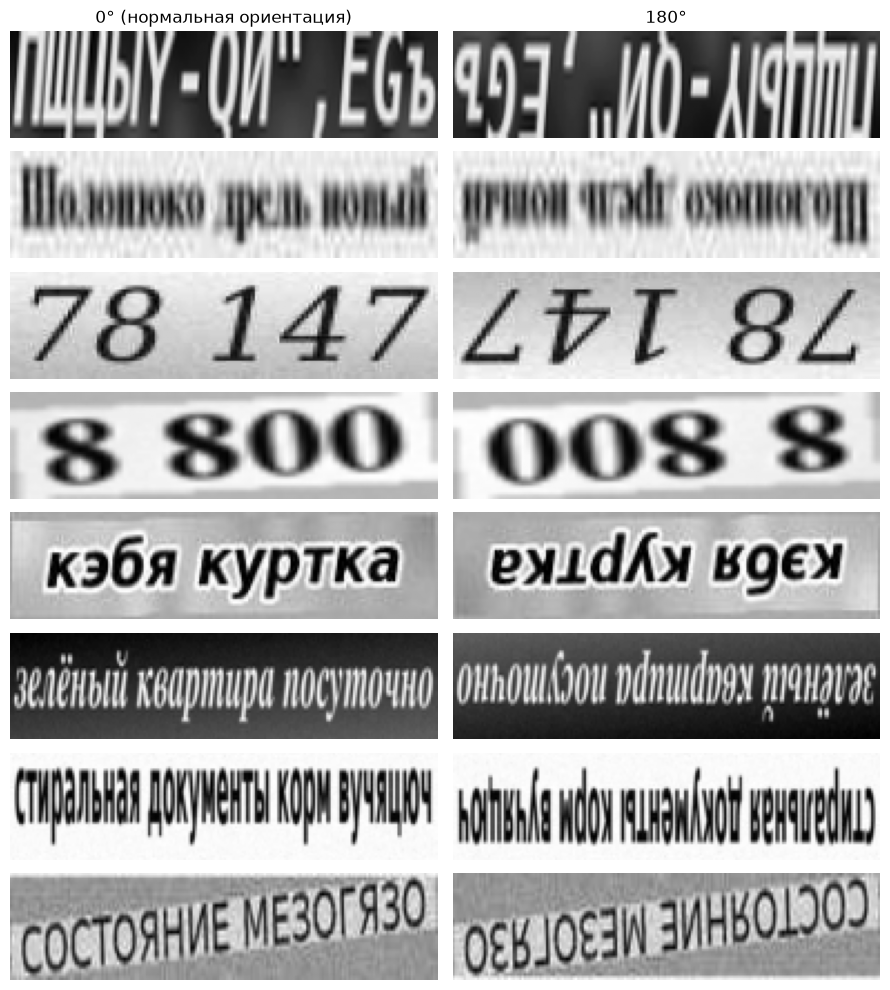

In [ ]:
# Предпросмотр синтетики: строки = разные примеры, 2 колонки = 0° и 180°
fig, axes = plt.subplots(8, 2, figsize=(9, 10))
prev = SynthDataset(8, base_seed=7)
for i in range(8):
    s = 7 * 1_000_003 + i
    im = to_model_input(render_crop(random.Random(s), np.random.default_rng(s)))
    axes[i, 0].imshow(im, cmap="gray"); axes[i, 0].axis("off")
    axes[i, 1].imshow(im[::-1, ::-1], cmap="gray"); axes[i, 1].axis("off")
axes[0, 0].set_title("0° (нормальная ориентация)"); axes[0, 1].set_title("180°")
plt.tight_layout(); plt.show()

## Раздел 5. Реальные тестовые кропы: загрузка и диагностика

Читаем все 20 000 кропов один раз в массив `uint8` (~180 МБ) и печатаем статистику размеров:
распределение пропорций и долю вертикальных кропов. Если вертикальных много — посмотрите на них глазами
и решите, нужен ли `ROTATE_VERTICAL`.

In [ ]:
def index_images(root: str):
    """stem (image_id без расширения) -> путь. Ищем рекурсивно, поэтому структура папок не важна."""
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    idx = {}
    for dp, _, fns in os.walk(root):
        for fn in sorted(fns):
            stem, ext = os.path.splitext(fn)
            if ext.lower() in exts:
                idx.setdefault(stem, os.path.join(dp, fn))
    return idx


path_index = index_images(TEST_DIR)

# image_id = имя файла без расширения; сортировка даёт детерминированный порядок строк
image_ids = sorted(path_index)
print("Найдено кропов (image_id в сабмите):", len(image_ids))
assert len(image_ids) > 0, f"В {TEST_DIR} не найдено картинок. Проверьте путь."

image_id в сабмите: 20000


Загружено 20000 кропов за 22 c, массив (20000, 48, 192), 184 МБ
ширина  (5/50/95%): [  61.  238. 1047.]
высота  (5/50/95%): [ 16.  42. 195.]
w/h     (5/50/95%): [ 2.32  4.89 14.45]
доля вертикальных (h > w): 0.0002


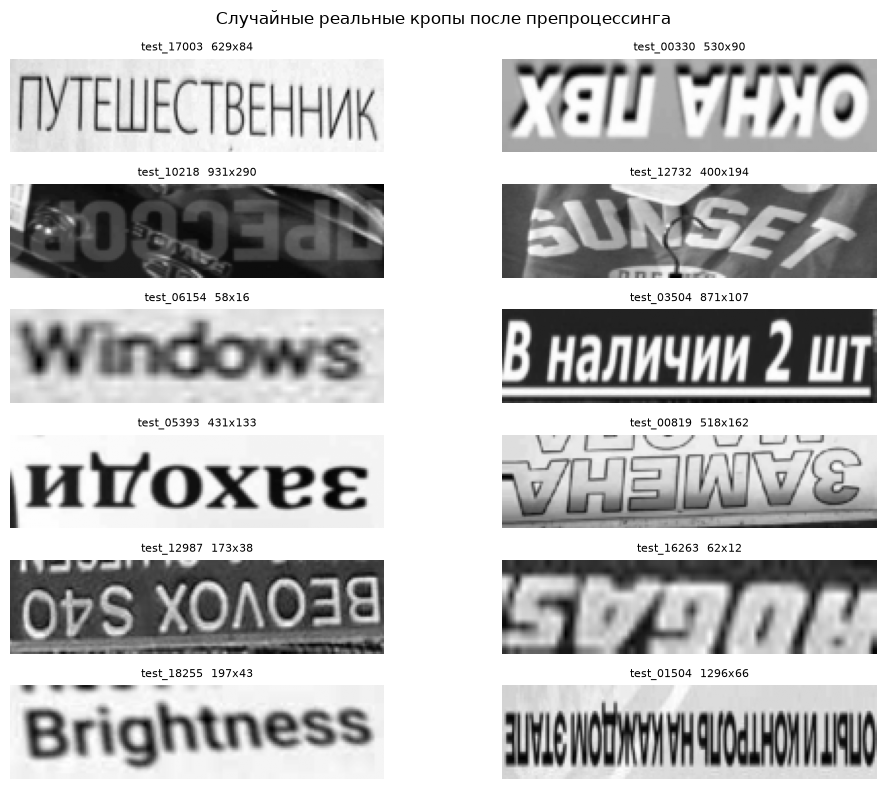

In [10]:
def load_test_crops(ids):
    X = np.zeros((len(ids), IMG_H, IMG_W), dtype=np.uint8)
    sizes = np.zeros((len(ids), 2), dtype=np.int32)          # (w, h) исходных кропов
    for k, image_id in enumerate(ids):
        with Image.open(path_index[image_id]) as im:
            im = im.convert("RGB") if im.mode in ("P", "RGBA", "LA") else im
            im = im.convert("L")
            sizes[k] = im.size
            if ROTATE_VERTICAL and im.size[1] > 1.5 * im.size[0]:
                im = im.transpose(getattr(Image, "Transpose", Image).ROTATE_90)
            X[k] = to_model_input(im)
    return X, sizes


t0 = time.time()
X_test, test_sizes = load_test_crops(image_ids)
print(f"Загружено {len(X_test)} кропов за {time.time() - t0:.0f} c, массив {X_test.shape}, {X_test.nbytes / 1e6:.0f} МБ")

w, h = test_sizes[:, 0].astype(float), test_sizes[:, 1].astype(float)
print("ширина  (5/50/95%):", np.percentile(w, [5, 50, 95]))
print("высота  (5/50/95%):", np.percentile(h, [5, 50, 95]))
print("w/h     (5/50/95%):", np.round(np.percentile(w / h, [5, 50, 95]), 2))
print("доля вертикальных (h > w):", round(float((h > w).mean()), 4))

fig, axes = plt.subplots(6, 2, figsize=(10, 8))
rs = np.random.default_rng(0)
for ax, k in zip(axes.ravel(), rs.choice(len(X_test), 12, replace=False)):
    ax.imshow(X_test[k], cmap="gray"); ax.axis("off"); ax.set_title(f"{image_ids[k]}  {int(w[k])}x{int(h[k])}", fontsize=8)
plt.suptitle("Случайные реальные кропы после препроцессинга"); plt.tight_layout(); plt.show()

## Раздел 6. Модель

Небольшая CNN: 5 свёрток (BN + ReLU) и 4 MaxPool, вход 1×48×192 → карта 3×12.
Голова: по ширине берём `mean` и `max` (положение по **вертикали** сохраняем — верх и низ строки, то есть
выносные элементы букв, несут главный сигнал об ориентации), затем два линейных слоя.

**Антисимметрия.** `forward(x) = (raw(x) − raw(rot180(x))) / 2`. Тогда `logit(rot180(x)) = −logit(x)`
строго, и `p(x) + p(rot180(x)) = 1` выполняется всегда — ни обучению, ни TTA не нужно этому учиться.

In [ ]:
class OrientationNet(nn.Module):
    def __init__(self, ch=(16, 32, 64, 64, 128), p_drop=0.2):
        super().__init__()
        c1, c2, c3a, c3b, c4 = ch

        def cbr(i, o):
            return [nn.Conv2d(i, o, 3, padding=1, bias=False), nn.BatchNorm2d(o), nn.ReLU(inplace=True)]

        layers = (cbr(1, c1) + [nn.MaxPool2d(2)] +            # 48x192 -> 24x96
                  cbr(c1, c2) + [nn.MaxPool2d(2)] +           # -> 12x48
                  cbr(c2, c3a) + cbr(c3a, c3b) + [nn.MaxPool2d(2)] +   # -> 6x24
                  cbr(c3b, c4) + [nn.MaxPool2d(2)])           # -> 3x12
        self.features = nn.Sequential(*layers)
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(p_drop),
                                  nn.Linear(c4 * 2 * 3, 64), nn.ReLU(inplace=True),
                                  nn.Dropout(p_drop), nn.Linear(64, 1))

    def raw(self, x):
        f = self.features(x) # (B, C, 3, 12)
        f = torch.cat([f.mean(dim=3), f.amax(dim=3)], dim=1) # (B, 2C, 3): сворачиваем ширину, высоту сохраняем
        return self.head(f).squeeze(1)

    def forward(self, x):
        both = self.raw(torch.cat([x, torch.flip(x, dims=[2, 3])], dim=0)) # один батч: x и rot180(x)
        a, b = both.chunk(2)
        return 0.5 * (a - b)


set_seed(SEED)
model = OrientationNet().to(DEVICE)
print("Параметров:", f"{sum(p.numel() for p in model.parameters()):,}")

Параметров: 183,665


## Раздел 7. Вспомогательные функции, валидация, TTA

Две **фиксированные** синтетические валидации (генерируются один раз):
* `val_easy` — обычные искажения (как в обучении);
* `val_hard` — усиленные искажения (мельче, размытее, контрастнее шум, сильнее JPEG и перспектива).
  Она нужна для калибровки: реальные данные почти наверняка ближе к жёсткой, чем к лёгкой выборке.

In [12]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def brier(p, y):
    return float(np.mean((p - y) ** 2))


def _batch(X, i, bs):
    xb = torch.as_tensor(X[i:i + bs])
    if xb.ndim == 3:                      # (B,H,W) -> (B,1,H,W)
        xb = xb.unsqueeze(1)
    return xb.to(DEVICE)


def tta_zoom(x, s=0.92):
    """Центральный кроп (92%) и возврат к размеру. Симметричен относительно центра -> совместим с антисимметрией."""
    _, _, H, W = x.shape
    h, w = int(H * s), int(W * s)
    t, l = (H - h) // 2, (W - w) // 2
    return F.interpolate(x[:, :, t:t + h, l:l + w], size=(H, W), mode="bilinear", align_corners=False)


def tta_pad(x, p=0.08):
    """Паддинг по краю (8%) и сжатие обратно — «более свободный» кроп."""
    _, _, H, W = x.shape
    ph, pw = int(H * p), int(W * p)
    xp = F.pad(x, (pw, pw, ph, ph), mode="replicate")
    return F.interpolate(xp, size=(H, W), mode="bilinear", align_corners=False)


@torch.no_grad()
def model_logits(net, X, tta=False, bs=512):
    """Логиты (N,) для uint8-массива/тензора. При tta усредняем логиты по 3 вариантам кропа."""
    net.eval()
    out = []
    for i in range(0, len(X), bs):
        x = normalize(_batch(X, i, bs))
        z = net(x)
        if tta:
            z = torch.stack([z, net(tta_zoom(x)), net(tta_pad(x))]).mean(0)
        out.append(z.float().cpu())
    return torch.cat(out).numpy()


assert EPOCHS * N_TRAIN_PER_EPOCH < 1_000_003, "seed-диапазоны train и val пересеклись бы"
t0 = time.time()
val_easy = materialize(SynthDataset(N_VAL, SEED + 1, hard=False))
val_hard = materialize(SynthDataset(N_VAL, SEED + 2, hard=True))
print(f"Валидации сгенерированы за {time.time() - t0:.0f} c")

C:\Users\Ditriy\AppData\Local\Temp\ipykernel_17308\1117687258.py:32: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  return torch.from_numpy(np.ascontiguousarray(arr)).unsqueeze(0), torch.tensor(float(label))


Валидации сгенерированы за 11 c


## Раздел 8. Обучение

* потери: BCE с небольшим label smoothing (мягкие цели -> меньше самоуверенности);
* оптимизатор AdamW + OneCycle; на каждой эпохе новая порция синтетики (детерминированно);
* на каждой эпохе печатаем `1 − Brier` на лёгкой и жёсткой валидации.

In [ ]:
history = []
if LOAD_WEIGHTS_IF_EXIST and os.path.exists(WEIGHTS_PATH):
    model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))
    print("Веса загружены из", WEIGHTS_PATH)
else:
    train_ds = SynthDataset(N_TRAIN_PER_EPOCH, SEED, hard=False)
    gen = torch.Generator()
    gen.manual_seed(SEED)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
                              num_workers=NUM_WORKERS, generator=gen)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=LR, epochs=EPOCHS,
                                                    steps_per_epoch=len(train_loader), pct_start=0.2)
    for epoch in range(EPOCHS):
        train_ds.offset = epoch * N_TRAIN_PER_EPOCH # новые примеры на каждой эпохе
        model.train()
        t0, run_loss, n_seen = time.time(), 0.0, 0

        for xb, yb in train_loader:
            x, y = normalize(xb.to(DEVICE)), yb.to(DEVICE)
            y_soft = y * (1 - 2 * LABEL_SMOOTHING) + LABEL_SMOOTHING
            loss = F.binary_cross_entropy_with_logits(model(x), y_soft)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            optimizer.step()
            scheduler.step()
            run_loss += loss.item() * len(y)
            n_seen += len(y)
        res = {"epoch": epoch + 1, "loss": run_loss / n_seen}

        for name, (Xv, yv) in (("easy", val_easy), ("hard", val_hard)):
            p = sigmoid(model_logits(model, Xv))
            res[f"{name}_acc"] = float(np.mean((p > 0.5) == yv.numpy()))
            res[f"{name}_1-brier"] = 1 - brier(p, yv.numpy())

        history.append(res)

        print(f"epoch {epoch + 1:2d}/{EPOCHS} | loss={res['loss']:.4f} | "
              f"easy: acc={res['easy_acc']:.4f} 1-B={res['easy_1-brier']:.4f} | "
              f"hard: acc={res['hard_acc']:.4f} 1-B={res['hard_1-brier']:.4f} | {time.time() - t0:.0f} c")
        
    torch.save(model.state_dict(), WEIGHTS_PATH)
    print("Веса сохранены:", WEIGHTS_PATH)

epoch  1/12 | loss=0.6222 | easy: acc=0.8035 1-B=0.8582 | hard: acc=0.7175 1-B=0.8162 | 233 c
epoch  2/12 | loss=0.3988 | easy: acc=0.8885 1-B=0.9189 | hard: acc=0.7910 1-B=0.8570 | 231 c
epoch  3/12 | loss=0.2918 | easy: acc=0.9415 1-B=0.9534 | hard: acc=0.8375 1-B=0.8861 | 236 c
epoch  4/12 | loss=0.2514 | easy: acc=0.9535 1-B=0.9595 | hard: acc=0.8550 1-B=0.8954 | 232 c
epoch  5/12 | loss=0.2228 | easy: acc=0.9570 1-B=0.9655 | hard: acc=0.8635 1-B=0.9043 | 230 c
epoch  6/12 | loss=0.2064 | easy: acc=0.9670 1-B=0.9708 | hard: acc=0.8725 1-B=0.9101 | 231 c
epoch  7/12 | loss=0.1909 | easy: acc=0.9710 1-B=0.9752 | hard: acc=0.8840 1-B=0.9172 | 229 c
epoch  8/12 | loss=0.1828 | easy: acc=0.9765 1-B=0.9786 | hard: acc=0.8840 1-B=0.9198 | 229 c
epoch  9/12 | loss=0.1777 | easy: acc=0.9820 1-B=0.9818 | hard: acc=0.8920 1-B=0.9253 | 230 c
epoch 10/12 | loss=0.1700 | easy: acc=0.9810 1-B=0.9823 | hard: acc=0.8920 1-B=0.9265 | 230 c
epoch 11/12 | loss=0.1679 | easy: acc=0.9820 1-B=0.9833 | ha

## Раздел 9. Калибровка температуры (по «жёсткой» валидации)

Подбираем `T`, минимизирующее Brier Score на `val_hard`: `p = sigmoid(z / T)`.
`T > 1` делает предсказания осторожнее. Реальные данные не размечены, поэтому именно эта выборка —
наш «страховочный» прокси для сдвига домена.

In [ ]:
z_hard, y_hard = model_logits(model, val_hard[0], tta=USE_TTA), val_hard[1].numpy()
z_easy, y_easy = model_logits(model, val_easy[0], tta=USE_TTA), val_easy[1].numpy()

grid = np.linspace(0.5, 8.0, 151)
TEMP = float(grid[int(np.argmin([brier(sigmoid(z_hard / T), y_hard) for T in grid]))])

print(f"Температура T = {TEMP:.2f}")

for name, z, y in (("easy", z_easy, y_easy), ("hard", z_hard, y_hard)):
    p0, p1 = sigmoid(z), np.clip(sigmoid(z / TEMP), *CLIP)
    print(f"{name}: 1-Brier до калибровки {1 - brier(p0, y):.4f} -> после {1 - brier(p1, y):.4f} "
          f"| acc {np.mean((p1 > 0.5) == y):.4f}")

Температура T = 0.70
easy: 1-Brier до калибровки 0.9827 -> после 0.9846 | acc 0.9810
hard: 1-Brier до калибровки 0.9281 -> после 0.9300 | acc 0.9010


## Раздел 10. Предсказания на тесте и диагностика

доля p > 0.5: 0.4983
доля уверенных (p<0.1 или p>0.9): 0.7073
средняя |p-0.5|: 0.3945
ожидаемый 1-Brier, если модель откалибрована на реальных данных: 0.9213 (константа 0.5 даёт 0.75)


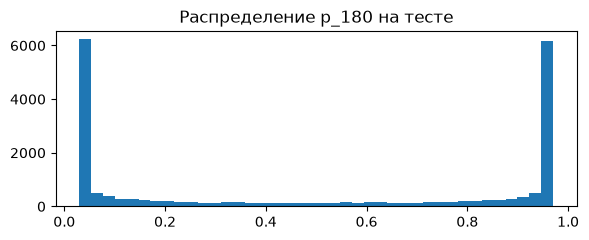

In [15]:
z_test = model_logits(model, X_test, tta=USE_TTA)
p_test = np.clip(sigmoid(z_test / TEMP), *CLIP)

print("доля p > 0.5:", round(float((p_test > 0.5).mean()), 4))
print("доля уверенных (p<0.1 или p>0.9):", round(float(((p_test < 0.1) | (p_test > 0.9)).mean()), 4))
print("средняя |p-0.5|:", round(float(np.abs(p_test - 0.5).mean()), 4))
print("ожидаемый 1-Brier, если модель откалибрована на реальных данных:",
      round(1 - float(np.mean(p_test * (1 - p_test))), 4), "(константа 0.5 даёт 0.75)")
plt.figure(figsize=(6, 2.5)); plt.hist(p_test, bins=40); plt.title("Распределение p_180 на тесте"); plt.tight_layout(); plt.show()

## Раздел 11. Сохранение submission.csv

In [ ]:
submission = pd.DataFrame({"image_id": image_ids, "p_180": np.round(p_test, 6)})

assert len(submission) == len(image_ids)
assert submission["image_id"].is_unique
assert submission["p_180"].notna().all() and submission["p_180"].between(0, 1).all()
submission.to_csv(OUTPUT_PATH, index=False)
print("Сохранено:", OUTPUT_PATH, submission.shape)
submission.head()

Сохранено: ./submission.csv (20000, 2)


,image_id,p_180
0,test_00000,0.205600
1,test_00001,0.853522
2,test_00002,0.970000
3,test_00003,0.149659
4,test_00004,0.970000


## Итоги и ограничения

* Синтетика не покрывает всё разнообразие реальных объявлений (специфичные шрифты, логотипы, вертикальный
  и рукописный текст)
* Строки из симметричных символов («0», «8», «О», «Х», «SOS»…) принципиально неоднозначны.
  Для них модель должна честно выдавать значения около 0.5, чему помогают label smoothing и калибровка.
* Домен-сдвиг: на реальных данных уверенность модели немного завышена (см. выше). Возможные улучшения —
  калибровка на реальной разметке, если она появится, более разнообразные шрифты, ансамбль моделей.

### Итоговая метрика

(1 − Brier) = 0.90146770; ошибка Брайера = 0.09853230


